In [1]:
# Download PDF file
import os
import requests

pdf_path = "MC.pdf"
if os.path.exists(pdf_path):
  print(f"File {pdf_path} exists.")

File MC.pdf exists.


In [2]:
import fitz 
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm 

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() 

    return cleaned_text

def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = text_formatter(text)
        pages_and_texts.append({"page_number": page_number - 11,  # adjust page numbers since our PDF starts on page 11
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[0]

0it [00:00, ?it/s]

{'page_number': -11,
 'page_char_count': 433,
 'page_word_count': 53,
 'page_sentence_count_raw': 6,
 'page_token_count': 108.25,
 'text': 'Technische Universit¨at Hamburg Data Science Foundations Morphological Computation as Intrinsic Reward for Reinforcement Learning Master’s Thesis am Institut Data Science Foundations Technische Universit¨at Hamburg vorgelegt von Omar Baiazid am 15.09.2024 Erstpr¨ufer: Prof. Dr. N. Ay Zweitpr¨ufer Dr. Manfred Eppe Betreuung: Dr. Manfred Eppe Omar Baiazid geboren am: 01.06.1998 Matrikelnummer: 21760121 Studiengang: Computer Science'}

In [3]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 17,
  'page_char_count': 2567,
  'page_word_count': 398,
  'page_sentence_count_raw': 23,
  'page_token_count': 641.75,
  'text': '2.3. Intrinsic Rewards in RL Empowerment Empowerment-based rewards are based on the idea that agents are motivated to increase their control over the environment. The intuition is that by rewarding the agent for actions that increase its ability to influence future states, it will be motivated to seek out and exploit opportunities for control. Empowerment rewards are given for actions that increase the agent’s ability to affect its environment. This can help the agent develop strategies that maximize its influence over future states. Empowerment can be measured using information-theoretic approaches, such as calculating the mutual information between the agent’s actions and the resulting states. The agent is rewarded for actions that increase this mutual information. Competence Competence-based rewards are inspired by the idea that agents a

In [4]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-11,433,53,6,108.25,Technische Universit¨at Hamburg Data Science F...
1,-10,0,1,1,0.00,
2,-9,2050,273,15,512.50,Abstract Abstract This thesis explores the int...
3,-8,11,2,1,2.75,Abstract IV
4,-7,2072,688,536,518.00,Contents 1 Introduction 1 1.1 Research Questio...


In [5]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,82.00,82.00,82.00,82.00,82.00
mean,29.50,1291.63,213.80,23.88,322.91
std,23.82,900.46,154.79,69.92,225.12
min,-11.00,0.00,1.00,1.00,0.00
25%,9.25,455.75,75.00,4.00,113.94
50%,29.50,1262.00,207.50,10.50,315.50
75%,49.75,2044.00,329.50,17.00,511.00
max,70.00,3180.00,688.00,536.00,795.00


In [6]:
from spacy.lang.en import English

nlp = English()

# Add a sentencizer pipeline, see https://spacy.io/api/sentencizer/ 
nlp.add_pipe("sentencizer")

In [7]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)
    
    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]
    
    # Count the sentences 
    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/82 [00:00<?, ?it/s]

In [8]:
random.sample(pages_and_texts, k=1)

[{'page_number': 1,
  'page_char_count': 2275,
  'page_word_count': 328,
  'page_sentence_count_raw': 17,
  'page_token_count': 568.75,
  'text': 'Chapter 2 Background This chapter offers a thorough overview of the essential concepts required for a deeper grasp of the thesis topic. Section 2.1 lays out the fundamental principles of probabilistic neural networks, which serve as the foundation for implementing and assessing Morphological Computation and thus calculating the intrinsic reward. Section 2.2 explores the core concepts of traditional Reinforcement Learning (RL), leading to a discussion on Deep Reinforcement Learning (DRL). We will focus on Actor-Critic methods, with particular emphasis on Soft Actor-Critic (SAC). Fi- nally, the chapter concludes by introducing Morphological Computation, following a review of several state-of-the-art intrinsic rewards. 2.1 Probabilistic Neural Networks For the implementation of Morphological Computation, we require specialized neu- ral networks

In [9]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,82.00,82.00,82.00,82.00,82.00,82.00
mean,29.50,1291.63,213.80,23.88,322.91,10.48
std,23.82,900.46,154.79,69.92,225.12,7.72
min,-11.00,0.00,1.00,1.00,0.00,0.00
25%,9.25,455.75,75.00,4.00,113.94,3.00
50%,29.50,1262.00,207.50,10.50,315.50,10.00
75%,49.75,2044.00,329.50,17.00,511.00,17.00
max,70.00,3180.00,688.00,536.00,795.00,34.00


In [10]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 10 

# A function that recursively splits a list into desired sizes
def split_list(input_list: list, 
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/82 [00:00<?, ?it/s]

In [11]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages_and_texts, k=1)

[{'page_number': 61,
  'page_char_count': 682,
  'page_word_count': 100,
  'page_sentence_count_raw': 4,
  'page_token_count': 170.5,
  'text': 'Anhang B. Additional Proofs Convergence of Q-Learning Q-Learning is guaranteed to converge to the optimal action-value function Q∗(s, a) under certain conditions, including that all state-action pairs continue to be up- dated, and the learning rate decreases appropriately. This convergence means that the agent can learn the best possible policy for the given environment, which can then be used to determine the optimal sequence of actions to maximize cumula- tive rewards. Thus, Q-Learning provides a robust framework for learning optimal policies in unknown environments, balancing exploration and exploitation through its update rule and the choice of policy during learning 63',
  'sentences': ['Anhang B. Additional Proofs Convergence of Q-Learning Q-Learning is guaranteed to converge to the optimal action-value function Q∗(s, a) under certain co

In [12]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,82.00,82.00,82.00,82.00,82.00,82.00,82.00
mean,29.50,1291.63,213.80,23.88,322.91,10.48,1.52
std,23.82,900.46,154.79,69.92,225.12,7.72,0.76
min,-11.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,9.25,455.75,75.00,4.00,113.94,3.00,1.00
50%,29.50,1262.00,207.50,10.50,315.50,10.00,1.00
75%,49.75,2044.00,329.50,17.00,511.00,17.00,2.00
max,70.00,3180.00,688.00,536.00,795.00,34.00,4.00


In [13]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]
        
        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" for any full-stop/capital letter combo 
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters
        
        pages_and_chunks.append(chunk_dict)

# How many chunks do we have?
len(pages_and_chunks)

  0%|          | 0/82 [00:00<?, ?it/s]

125

In [14]:
# View a random sample
random.sample(pages_and_chunks, k=1)

[{'page_number': 50,
  'sentence_chunk': 'Chapter 4. Experiments, Results and Discussion (d) Landing and proceeding (e) Achieving the goal Figure 4.15: The agent moves at full speed toward the goal, sometimes resulting in it standing on two legs or even jumping. Despite these actions, it remains stable and tries to utilize every joint movement to its full potential.52',
  'chunk_char_count': 328,
  'chunk_word_count': 53,
  'chunk_token_count': 82.0}]

In [15]:
# Get stats about our chunks
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,125.00,125.00,125.00,125.00
mean,26.30,845.85,139.14,211.46
std,22.76,518.30,87.47,129.57
min,-11.00,2.00,1.00,0.50
25%,8.00,370.00,62.00,92.50
50%,23.00,871.00,146.00,217.75
75%,45.00,1222.00,199.00,305.50
max,69.00,1903.00,345.00,475.75


In [16]:
# Show random chunks with under 30 tokens in length
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 4.0 | Text: List of Tables X
Chunk token count: 6.0 | Text: Chapter 2. Background 22
Chunk token count: 5.0 | Text: List of Figures VIII
Chunk token count: 6.25 | Text: Anhang A. Nomenclature 60
Chunk token count: 2.75 | Text: Abstract IV


In [17]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -11,
  'sentence_chunk': 'Technische Universit¨at Hamburg Data Science Foundations Morphological Computation as Intrinsic Reward for Reinforcement Learning Master’s Thesis am Institut Data Science Foundations Technische Universit¨at Hamburg vorgelegt von Omar Baiazid am 15.09.2024 Erstpr¨ufer: Prof. Dr. N. Ay Zweitpr¨ufer Dr. Manfred Eppe Betreuung: Dr. Manfred Eppe Omar Baiazid geboren am: 01.06.1998 Matrikelnummer: 21760121 Studiengang: Computer Science',
  'chunk_char_count': 433,
  'chunk_word_count': 53,
  'chunk_token_count': 108.25},
 {'page_number': -9,
  'sentence_chunk': 'Abstract Abstract This thesis explores the integration of Morphological Computation (MC) as an intrinsic reward to Reinforcement Learning (RL). Integrating MC to RL is a novel method designed to accelerate and enhance the learning process. By incorporating the agent’s physical properties into the learning algorithm, MC helps optimize the actions taken by the agent to leverage the dynamics in

In [18]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", 
                                      device="cpu") # choose the device to load the model to (note: GPU will often be *much* faster than CPU)

# Create a list of sentences to turn into numbers
sentences = [
    "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded one by one or as a list of strings.",
    "Embeddings are one of the most powerful concepts in machine learning!",
    "Learn to use embeddings well and you'll be well on your way to being an AI engineer."
]

# Sentences are encoded/embedded by calling model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

/home/omar/miniconda3/envs/LLM/lib/python3.12/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/omar/miniconda3/envs/LLM/lib/python3.12/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Sentence: The Sentences Transformers library provides an easy and open-source way to create embeddings.
Embedding: [-2.07982622e-02  3.03164814e-02 -2.01217756e-02  6.86484724e-02
 -2.55255774e-02 -8.47685337e-03 -2.07218472e-04 -6.32377639e-02
  2.81606689e-02 -3.33353579e-02  3.02634202e-02  5.30721582e-02
 -5.03527001e-02  2.62288768e-02  3.33313718e-02 -4.51577678e-02
  3.63044962e-02 -1.37117901e-03 -1.20171234e-02  1.14947204e-02
  5.04510775e-02  4.70856763e-02  2.11913791e-02  5.14606833e-02
 -2.03746688e-02 -3.58889587e-02 -6.67777669e-04 -2.94393674e-02
  4.95859347e-02 -1.05639519e-02 -1.52014149e-02 -1.31757243e-03
  4.48197536e-02  1.56023204e-02  8.60379600e-07 -1.21390796e-03
 -2.37978715e-02 -9.09364608e-04  7.34486431e-03 -2.53929570e-03
  5.23370318e-02 -4.68043610e-02  1.66214649e-02  4.71579507e-02
 -4.15599383e-02  9.01921652e-04  3.60277891e-02  3.42214331e-02
  9.68227759e-02  5.94829284e-02 -1.64984278e-02 -3.51249315e-02
  5.92514174e-03 -7.07938452e-04 -2.4103

In [19]:
single_sentence = "Computer Scientists are the best Mathematicians and Engineers at once"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Computer Scientists are the best Mathematicians and Engineers at once
Embedding:
[-2.18874235e-02  4.40576449e-02 -4.81773093e-02  1.12021118e-02
  1.15972543e-02  3.24212424e-02  9.45310108e-03 -4.33624350e-02
  1.30155943e-02  3.02732587e-02  3.65643576e-02 -4.76914429e-04
 -5.01571409e-03  4.69184630e-02  5.75279305e-03 -1.48637565e-02
  1.13068493e-02  3.84668820e-03 -2.10018195e-02 -4.87770839e-03
 -2.25306582e-02  1.84770674e-02 -3.65218073e-02  8.62568617e-03
  2.94655878e-02 -3.22562046e-02  7.92818666e-02 -2.88232733e-02
  4.71008569e-03  4.13995087e-02  8.33044387e-03 -5.83865345e-02
 -4.97636534e-02  4.91975546e-02  1.17470324e-06 -3.54938656e-02
  6.63110986e-03  8.04671347e-02 -1.58436596e-02  1.64891817e-02
 -2.46147364e-02  1.69727542e-02  8.78386106e-03  3.20432708e-02
 -3.07752434e-02  7.32933283e-02  1.52222263e-02 -1.87481928e-03
 -1.17380265e-02  8.27145111e-03  7.86027499e-03 -1.25134774e-02
 -7.19681336e-03 -3.09719064e-04 -7.62416748e-03 -5.76760294e-03

In [20]:
%%time

# Send the model to the GPU
embedding_model.to("cuda")

# Create embeddings one by one on the GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

  0%|          | 0/110 [00:00<?, ?it/s]

CPU times: user 16.2 s, sys: 141 ms, total: 16.3 s
Wall time: 1.63 s


In [21]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [22]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=32, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

CPU times: user 2.14 s, sys: 10.5 ms, total: 2.15 s
Wall time: 1.35 s


tensor([[ 0.0010, -0.0001, -0.0443,  ...,  0.0399,  0.0290, -0.0515],
        [ 0.0196,  0.0024, -0.0236,  ...,  0.0659,  0.0205, -0.0377],
        [-0.0165, -0.0260, -0.0112,  ...,  0.0519,  0.0351, -0.0284],
        ...,
        [-0.0504, -0.0109, -0.0095,  ...,  0.1066,  0.0321, -0.0096],
        [ 0.0199, -0.0095,  0.0183,  ...,  0.0184, -0.0675, -0.0160],
        [ 0.0212, -0.0205,  0.0064,  ...,  0.0070, -0.0531, -0.0472]],
       device='cuda:0')

In [23]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [24]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-11,Technische Universit¨at Hamburg Data Science F...,433,53,108.25,[ 1.00360531e-03 -1.14718132e-04 -4.43102792e-...
1,-9,Abstract Abstract This thesis explores the int...,1445,200,361.25,[ 1.95823126e-02 2.39899475e-03 -2.35961732e-...
2,-9,"Unser Ansatz konzentriert sich da- rauf, den S...",604,73,151.00,[-1.65464468e-02 -2.59631705e-02 -1.11725191e-...
3,-7,Contents 1 Introduction 1 1.1 Research Questio...,833,257,208.25,[ 2.30155643e-02 6.13312749e-03 1.26514467e-...
4,-7,14 2.3 Intrinsic Rewards in RL . . . . . . . ....,815,268,203.75,[-7.04301894e-03 -1.82368904e-02 -1.03967236e-...


In [25]:
import random

import torch
import numpy as np 
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape

torch.Size([110, 768])

In [26]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-11,Technische Universit¨at Hamburg Data Science F...,433,53,108.25,"[0.00100360531, -0.000114718132, -0.0443102792..."
1,-9,Abstract Abstract This thesis explores the int...,1445,200,361.25,"[0.0195823126, 0.00239899475, -0.0235961732, -..."
2,-9,"Unser Ansatz konzentriert sich da- rauf, den S...",604,73,151.00,"[-0.0165464468, -0.0259631705, -0.0111725191, ..."
3,-7,Contents 1 Introduction 1 1.1 Research Questio...,833,257,208.25,"[0.0230155643, 0.00613312749, 0.00126514467, 0..."
4,-7,14 2.3 Intrinsic Rewards in RL . . . . . . . ....,815,268,203.75,"[-0.00704301894, -0.0182368904, -0.0103967236,..."


In [27]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", 
                                      device=device) # choose the device to load the model to

/home/omar/miniconda3/envs/LLM/lib/python3.12/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [28]:
# 1. Define the query
query = "Morphological Computation"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples 
# Note: It's important to embed your query with the same model you embedded your examples with.
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Get similarity scores with the dot product (we'll time this for fun)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: Morphological Computation
Time take to get scores on 110 embeddings: 0.00040 seconds.


torch.return_types.topk(
values=tensor([0.6748, 0.6373, 0.5724, 0.5567, 0.5546], device='cuda:0'),
indices=tensor([102,   0,  91,  47,  94], device='cuda:0'))

In [29]:
larger_embeddings = torch.randn(100*embeddings.shape[0], 768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across 168,000 embeddings
start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=larger_embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(larger_embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

Embeddings shape: torch.Size([11000, 768])
Time take to get scores on 11000 embeddings: 0.00347 seconds.


In [30]:
# Define helper function to print wrapped text 
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [31]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'Morphological Computation'

Results:
Score: 0.6748
Text:
Bibliography [1] Manfred Eppe, Adwait Datar, Carlotta Langer, Danny Cam Hoa
Tien, Fin Armbrecht, Frank R¨oder, Jan Dohmen, Leon Kruse, Leon Sierau, Maik
Marius Rebaum, and Omar Baiazid. Scilab-rl, 2024. Created: November 02, 2021.
[2] Keyan Ghazi-Zahedi, Raphael Deimel, Guido Mont´ufar, Vincent Wall, and
Oliver Brock. Morphological computation: The good, the bad, and the ugly. IEEE,
September 2017. [3] Tuomas Haarnoja, Aurick Zhou, Kristian Hartikainen, George
Tucker, Sehoon Ha, Jie Tan, Vikash Kumar, Henry Zhu, Abhishek Gupta, Pieter
Abbeel, and Sergey Levine. Soft actor-critic algorithms and applications.arXiv
preprint arXiv:1812.05905, 2018. Available online at https://arxiv.org/abs/1812.
Page number: 65


Score: 0.6373
Text:
Technische Universit¨at Hamburg Data Science Foundations Morphological
Computation as Intrinsic Reward for Reinforcement Learning Master’s Thesis am
Institut Data Science Foundations Technische Un

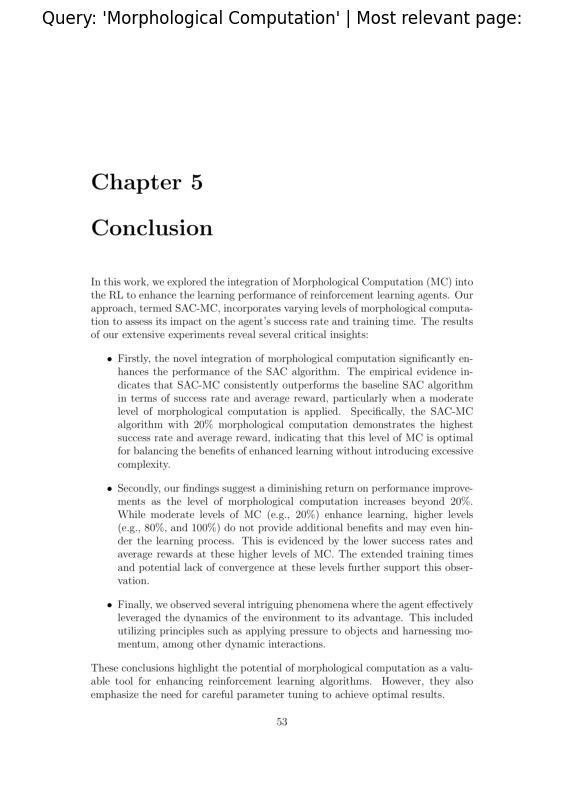

In [32]:
# import fitz

# Open PDF and load target page
pdf_path = "MC.pdf" # requires PDF to be downloaded
doc = fitz.open(pdf_path)
page = doc.load_page(51 + 11) # number of page (our doc starts page numbers on page 41)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv, 
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

In [33]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Get Euclidean/L2 norm of each vector (removes the magnitude, keeps direction)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

In [34]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query, 
                                   convert_to_tensor=True) 

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores, 
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """
    
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)
    
    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

In [35]:
query = "SAC"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 110 embeddings: 0.00003 seconds.


(tensor([0.3938, 0.3060, 0.3023, 0.3006, 0.2771], device='cuda:0'),
 tensor([ 9, 70, 95, 84, 61], device='cuda:0'))

In [36]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 110 embeddings: 0.00007 seconds.
Query: SAC

Results:
Score: 0.3938
List of Tables 4.1 Action space details . . . . . . . . . . . . . . . . . . . .
. . . . . . .30 4.2 Baseline SAC Performance . . . . . . . . . . . . . . . . . .
. . . . .33 4.3 SAC-MC with α = 0.2 . . . . . . . . . . . . . . . . . . . . . .
. . .34 4.4 Baseline SAC Performance . . . . . . . . . . . . . . . . . . . . . .
.46 4.5 SAC-MC α = 0.2 . . . . . . . . . . . . . . . . . . . . . . . . . . . .47
A.1 SAC Parameter for FetchPush . . . . . . . . . . . . . . . . . . . . .57 A.2
SAC-MC Parameter for FetchPush . . . . . . . . . . . . . . . . . .58 A.3 SAC
Parameter for AntMaze . . . . . . . . . . . . . . . . . . . . . .58 A.4 SAC-MC
Parameter for AntMaze . . . . . . . . . . . . . . . . . . .59 C.1 SAC-MC for
AntMaze with 94th percentile . . . . . . . . . . . . . .
Page number: -3


Score: 0.3060
Chapter 4. Experiments, Results and Discussion SAC-MC Performance The best-
performing model

In [37]:
# Get GPU available memory
import torch
gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2**30))
print(f"Available GPU memory: {gpu_memory_gb} GB")

Available GPU memory: 12 GB


In [39]:
use_quantization_config = False 
model_id = "google/gemma-2b-it" # "google/gemma-7b-it" # "google/gemma-2b-it"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")

use_quantization_config set to: False
model_id set to: google/gemma-2b-it


In [40]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available 


from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         bnb_4bit_compute_dtype=torch.float16)

if (is_flash_attn_2_available()) and (torch.cuda.get_device_capability(0)[0] >= 8):
  attn_implementation = "flash_attention_2"
else:
  attn_implementation = "sdpa"
print(f"[INFO] Using attention implementation: {attn_implementation}")


model_id = model_id 
print(f"[INFO] Using model_id: {model_id}")

# 3. Instantiate tokenizer (tokenizer turns text into numbers ready for the model) 
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)

# 4. Instantiate the model
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_id, 
                                                 torch_dtype=torch.float16, # datatype to use, we want float16
                                                 quantization_config=quantization_config if use_quantization_config else None,
                                                 low_cpu_mem_usage=False, # use full memory 
                                                 attn_implementation=attn_implementation) # which attention version to use

if not use_quantization_config: # quantization takes care of device setting automatically, so if it's not used, send model to GPU 
    llm_model.to("cuda")

[INFO] Using attention implementation: sdpa
[INFO] Using model_id: google/gemma-2b-it


/home/omar/miniconda3/envs/LLM/lib/python3.12/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [41]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): GemmaRotaryEmbedding()
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm()
        (post_attention_layernorm): GemmaRMSNorm()
      )
    )
    (norm): GemmaRM

In [42]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

2506172416

In [43]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.

    See: https://discuss.pytorch.org/t/gpu-memory-that-model-uses/56822
    """
    # Get model parameters and buffer sizes
    mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

    # Calculate various model sizes
    model_mem_bytes = mem_params + mem_buffers # in bytes
    model_mem_mb = model_mem_bytes / (1024**2) # in megabytes
    model_mem_gb = model_mem_bytes / (1024**3) # in gigabytes

    return {"model_mem_bytes": model_mem_bytes,
            "model_mem_mb": round(model_mem_mb, 2),
            "model_mem_gb": round(model_mem_gb, 2)}

get_model_mem_size(llm_model)

{'model_mem_bytes': 5079453696, 'model_mem_mb': 4844.14, 'model_mem_gb': 4.73}

In [44]:
input_text = "What is Actor-Critic?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {"role": "user",
     "content": input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False, # keep as raw text (not tokenized)
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
What is Actor-Critic?

Prompt (formatted):
<bos><start_of_turn>user
What is Actor-Critic?<end_of_turn>
<start_of_turn>model



In [45]:
%%time

# Tokenize the input text (turn it into numbers) and send it to GPU
input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")
print(f"Model input (tokenized):\n{input_ids}\n")

# Generate outputs passed on the tokenized input
# See generate docs: https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig 
outputs = llm_model.generate(**input_ids,
                             max_new_tokens=256) # define the maximum number of new tokens to create
print(f"Model output (tokens):\n{outputs[0]}\n")

Model input (tokenized):
{'input_ids': tensor([[     2,      2,    106,   1645,    108,   1841,    603,  43969, 235290,
         165000, 235336,    107,    108,    106,   2516,    108]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

Model output (tokens):
tensor([     2,      2,    106,   1645,    108,   1841,    603,  43969, 235290,
        165000, 235336,    107,    108,    106,   2516,    108,   1969,  14250,
        235290,  86695,    603,    476,   1552,   1064,    603,   2145,    671,
         14250,    578,    476,  15989, 235265,   2365,    708,   3326,    577,
          3658,    476,   6239,  14320,    611,   2145,    573,  28114,    578,
          9523,  12464,    576,    476,   3542, 235265,   2365,    708,   3695,
         12777,    685,   4592,  35793, 235269,    901,    798,   1170,    614,
          1942,    575,   1156,   7969,   1582,    685,  25506, 235269,   4296,
        235269,    578,  1233

In [46]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<bos><bos><start_of_turn>user
What is Actor-Critic?<end_of_turn>
<start_of_turn>model
An actor-critic is a person who is both an actor and a critic. They are able to provide a unique perspective on both the artistic and critical aspects of a project. They are often employed as film critics, but can also be found in other fields such as theatre, music, and literature.<eos>



In [47]:
print(f"Input text: {input_text}\n")
print(f"Output text:\n{outputs_decoded.replace(prompt, '').replace('<bos>', '').replace('<eos>', '')}")

Input text: What is Actor-Critic?

Output text:
An actor-critic is a person who is both an actor and a critic. They are able to provide a unique perspective on both the artistic and critical aspects of a project. They are often employed as film critics, but can also be found in other fields such as theatre, music, and literature.


In [48]:
gpt4_questions = [
    "What is the concept of Reinforcement Learning ?",
    "Explain to me what intrinsic rewards are?",
    "Can RL solve the exploration problem wihtout intrinsic Rewards?"
]

manual_questions = [
    "What is Morphological Computation?",
    "What is the Kullback-Leibler Divergence?",
    "How can we Implement MC as intrinsic reward?",
    "For what areas in RL can MC as intrinsic Reward be beneficial?",
    "Can we combine SAC algorithm with Morphological Computation"
]

query_list = gpt4_questions + manual_questions

In [49]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: Can we combine SAC algorithm with Morphological Computation
[INFO] Time taken to get scores on 110 embeddings: 0.00002 seconds.


(tensor([0.6144, 0.5914, 0.5564, 0.5392, 0.4973], device='cuda:0'),
 tensor([ 94,  68, 102,   0,  90], device='cuda:0'))

In [50]:
def prompt_formatter(query: str, 
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    # Join context items into one dotted paragraph
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Create a base prompt with examples to help the model
    # Note: this is very customizable, I've chosen to use 3 examples of the answer style we'd like.
    # We could also write this in a txt file and import it in if we wanted.
    base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.
\nExample 1:
Query: What are extrinsic Rewards?
Answer: Extrinsic rewards are external incentives like prizes, medals, or grades. Another child might be driven to perform tasks primarily to earn these rewards, such as winning a race to get a gold medal or completing homework to receive praise from parents or teachers.
\nExample 2:
Query: What are Markov Decision Process?
Answer: 
An MDP is defined by a five-tuple (S, A, P, R, γ), where:• S, A and R are states, actions and rewards respectively• P : The state transition probability function, P (st , at , st+1 ), which representsthe probability of transitioning to state st+1 P from state st after taking action at . Formally, P : S × A × S → [0, 1], where s′ ∈S P (st , at , st+1 ) = 1.
• γ: The discount factor, γ ∈ [0, 1], which is used to discount future rewards
to their present value. It captures the notion that immediate rewards are
generally more valuable than future rewards. A discount factor close to 1
indicates that future rewards are almost as important as immediate ones,
while a factor close to 0 emphasizes short-term rewards.
\nExample 3:
Query: What is the importance of Intrinsic Rewards?
Answer: Intrinsic Rewards are important for exploration-exploitaion problem in RL, in general RL tends to achieve the immediate and biggest reward but this should not be optimal, it could be that a later reward is bigger, which undermines the importance of the intrinsic rewards, which mainly serve exploration.
\nNow use the following context items to answer the user query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    # Update base prompt with context items and query   
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

In [51]:
query = random.choice(query_list)
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
    
# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print(prompt)

Query: Can RL solve the exploration problem wihtout intrinsic Rewards?
[INFO] Time taken to get scores on 110 embeddings: 0.00003 seconds.
<bos><start_of_turn>user
Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

Example 1:
Query: What are extrinsic Rewards?
Answer: Extrinsic rewards are external incentives like prizes, medals, or grades. Another child might be driven to perform tasks primarily to earn these rewards, such as winning a race to get a gold medal or completing homework to receive praise from parents or teachers.

Example 2:
Query: What are Markov Decision Process?
Answer: 
An MDP is defined by a five-tuple (S, A, P, R, γ), where:• S, A and R are states, actions and rewards respectivel

In [52]:
%%time

input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             temperature=0.7, # lower temperature = more deterministic outputs, higher temperature = more creative outputs
                             do_sample=True, # whether or not to use sampling, see https://huyenchip.com/2024/01/16/sampling.html for more
                             max_new_tokens=256) # how many new tokens to generate from prompt 

# Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: Can RL solve the exploration problem wihtout intrinsic Rewards?
RAG answer:
<bos>The context does not provide any information about whether RL can solve the exploration problem without intrinsic rewards, so I cannot answer this query from the provided context.<eos>
CPU times: user 1.09 s, sys: 17.3 ms, total: 1.1 s
Wall time: 1.12 s


In [53]:
def ask(query, 
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True, 
        return_answer_only=True):
    """
    Takes a query, finds relevant resources/context and generates an answer to the query based on the relevant resources.
    """
    
    # Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)
    
    # Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu() # return score back to CPU 
        
    # Format the prompt with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)
    
    # Tokenize the prompt
    input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature,
                                 do_sample=True,
                                 max_new_tokens=max_new_tokens)
    
    # Turn the output tokens into text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Replace special tokens and unnecessary help message
        output_text = output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").replace("Sure, here is the answer to the user query:\n\n", "")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text
    
    return output_text, context_items

In [54]:
query = random.choice(query_list)
print(f"Query: {query}")

# Answer query with context and return context 
answer, context_items = ask(query=query, 
                            temperature=0.7,
                            max_new_tokens=512,
                            return_answer_only=False)

print(f"Answer:\n")
print_wrapped(answer)
print(f"Context items:")
context_items

Query: What is Morphological Computation?
[INFO] Time taken to get scores on 110 embeddings: 0.00002 seconds.
Answer:

The passage describes morphological computation as the exploration and
exploitation of information gained from physical form and dynamics. It
emphasizes the role of the body's physical characteristics in optimizing control
and enhancing the efficiency of performing tasks.
Context items:


[{'page_number': -11,
  'sentence_chunk': 'Technische Universit¨at Hamburg Data Science Foundations Morphological Computation as Intrinsic Reward for Reinforcement Learning Master’s Thesis am Institut Data Science Foundations Technische Universit¨at Hamburg vorgelegt von Omar Baiazid am 15.09.2024 Erstpr¨ufer: Prof. Dr. N. Ay Zweitpr¨ufer Dr. Manfred Eppe Betreuung: Dr. Manfred Eppe Omar Baiazid geboren am: 01.06.1998 Matrikelnummer: 21760121 Studiengang: Computer Science',
  'chunk_char_count': 433,
  'chunk_word_count': 53,
  'chunk_token_count': 108.25,
  'embedding': array([ 1.00360531e-03, -1.14718132e-04, -4.43102792e-02,  9.91956890e-03,
         -5.31281233e-02, -9.88988206e-03, -3.51073965e-02,  1.14491479e-02,
         -1.03792980e-01,  5.89068495e-02, -3.42358015e-02, -2.71726064e-02,
          1.98591482e-02,  1.61287114e-02, -2.27244757e-03, -8.49943906e-02,
          1.06608281e-02,  5.36935440e-05,  3.84220434e-03, -3.17844860e-02,
          1.48794409e-02, -3.78523432e-